In [ ]:
%pip install numpy matplotlib numba -q


In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

SEED = 592
N = 30_000
R_REPS = 20
LAMBDA = 1.0
S = 1.0
L = 1.0
BALL_DIRS = 2000
D_BALLS = (5, 10)
D_FINITE = 5

rng_global = np.random.default_rng(SEED)


In [2]:
@njit
def sample_theta_star_ball(d, seed):
    np.random.seed(seed)
    x = np.random.normal(0.0, 1.0, size=d)
    nrm = np.sqrt(np.dot(x, x))
    if nrm < 1e-12:
        x[0] = 1.0
        nrm = 1.0
    return x / nrm


@njit
def sherman_morrison_update(invV, a):
    # inv(V + a a^T) = invV - invV a a^T invV / (1 + a^T invV a)
    v = invV @ a
    den = 1.0 + np.dot(a, v)
    invV -= np.outer(v, v) / den


@njit
def _run_oful_ball(n, d, theta_star, directions, seed):
    np.random.seed(seed)
    invV = (1.0 / LAMBDA) * np.eye(d)
    b = np.zeros(d)
    regrets = np.empty(n)
    cum_regret = 0.0

    theta_norm = np.sqrt(np.dot(theta_star, theta_star))
    r_star = theta_norm  # best expected reward on unit ball

    sqrt_beta = 1.0 + np.sqrt(2.0 * np.log(n) + d * np.log(1.0 + n * S * S * L * L / d))

    k = directions.shape[0]
    for t in range(n):
        hat_theta = invV @ b

        best_idx = 0
        best_ucb = -1e100
        for i in range(k):
            a = directions[i]
            mean_part = np.dot(a, hat_theta)
            bonus = sqrt_beta * np.sqrt(np.dot(a, invV @ a))
            ucb = mean_part + bonus
            if ucb > best_ucb:
                best_ucb = ucb
                best_idx = i

        a_t = directions[best_idx]
        noise = np.random.normal(0.0, 1.0)
        reward = np.dot(a_t, theta_star) + noise

        b += reward * a_t
        sherman_morrison_update(invV, a_t)

        instant_regret = r_star - np.dot(a_t, theta_star)
        cum_regret += instant_regret
        regrets[t] = cum_regret

    return regrets


@njit
def _run_oful_finite(n, actions, theta_star, seed):
    np.random.seed(seed)
    k, d = actions.shape
    invV = (1.0 / LAMBDA) * np.eye(d)
    b = np.zeros(d)
    regrets = np.empty(n)
    cum_regret = 0.0

    best_exp = -1e100
    for i in range(k):
        val = np.dot(actions[i], theta_star)
        if val > best_exp:
            best_exp = val

    sqrt_beta = 1.0 + np.sqrt(2.0 * np.log(n) + d * np.log(1.0 + n * S * S * L * L / d))

    for t in range(n):
        hat_theta = invV @ b

        best_idx = 0
        best_ucb = -1e100
        for i in range(k):
            a = actions[i]
            mean_part = np.dot(a, hat_theta)
            bonus = sqrt_beta * np.sqrt(np.dot(a, invV @ a))
            ucb = mean_part + bonus
            if ucb > best_ucb:
                best_ucb = ucb
                best_idx = i

        a_t = actions[best_idx]
        noise = np.random.normal(0.0, 1.0)
        reward = np.dot(a_t, theta_star) + noise

        b += reward * a_t
        sherman_morrison_update(invV, a_t)

        instant_regret = best_exp - np.dot(a_t, theta_star)
        cum_regret += instant_regret
        regrets[t] = cum_regret

    return regrets


@njit
def _run_ucb1_finite(n, actions, theta_star, seed):
    np.random.seed(seed)
    k, _ = actions.shape
    regrets = np.empty(n)
    cum_regret = 0.0

    arm_means = np.zeros(k)
    for i in range(k):
        arm_means[i] = np.dot(actions[i], theta_star)
    best_exp = np.max(arm_means)

    counts = np.zeros(k)
    sums = np.zeros(k)

    t = 0
    for i in range(k):
        if t >= n:
            break
        noise = np.random.normal(0.0, 1.0)
        reward = arm_means[i] + noise
        counts[i] += 1.0
        sums[i] += reward
        cum_regret += best_exp - arm_means[i]
        regrets[t] = cum_regret
        t += 1

    while t < n:
        log_term = np.log(t + 1.0)
        best_idx = 0
        best_ucb = -1e100
        for i in range(k):
            avg = sums[i] / counts[i]
            bonus = np.sqrt(2.0 * log_term / counts[i])
            ucb = avg + bonus
            if ucb > best_ucb:
                best_ucb = ucb
                best_idx = i

        noise = np.random.normal(0.0, 1.0)
        reward = arm_means[best_idx] + noise
        counts[best_idx] += 1.0
        sums[best_idx] += reward

        cum_regret += best_exp - arm_means[best_idx]
        regrets[t] = cum_regret
        t += 1

    return regrets


In [3]:
@njit(parallel=True)
def run_oful_ball_batch(n, d, theta_stars, directions, seeds):
    r = len(seeds)
    out = np.empty((r, n))
    for i in prange(r):
        out[i] = _run_oful_ball(n, d, theta_stars[i], directions[i], seeds[i])
    return out


@njit(parallel=True)
def run_oful_finite_batch(n, actions, theta_stars, seeds):
    r = len(seeds)
    out = np.empty((r, n))
    for i in prange(r):
        out[i] = _run_oful_finite(n, actions, theta_stars[i], seeds[i])
    return out


@njit(parallel=True)
def run_ucb1_finite_batch(n, actions, theta_stars, seeds):
    r = len(seeds)
    out = np.empty((r, n))
    for i in prange(r):
        out[i] = _run_ucb1_finite(n, actions, theta_stars[i], seeds[i])
    return out


In [4]:
def mean_and_se(curves):
    mean = curves.mean(axis=0)
    se = curves.std(axis=0, ddof=1) / np.sqrt(curves.shape[0])
    return mean, se


def plot_with_se(ax, x, mean, se, label):
    ax.plot(x, mean, label=label)
    ax.fill_between(x, mean - se, mean + se, alpha=0.2)


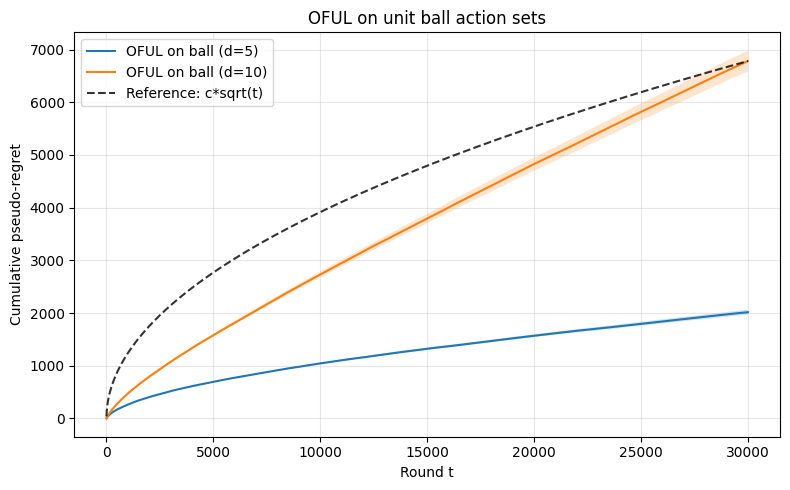

In [7]:
# Experiment 1: OFUL on B_d(0,1) for d=5 and d=10
x = np.arange(1, N + 1)
rep_seeds = rng_global.integers(1, 10**9, size=R_REPS)

fig, ax = plt.subplots(figsize=(8, 5))

for d in D_BALLS:
    theta_stars = np.empty((R_REPS, d))
    directions = np.empty((R_REPS, BALL_DIRS, d))

    for i in range(R_REPS):
        local_rng = np.random.default_rng(int(rep_seeds[i] + 37 * d + i))
        th = local_rng.normal(size=d)
        th /= np.linalg.norm(th)
        theta_stars[i] = th

        dirs = local_rng.normal(size=(BALL_DIRS, d))
        dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
        directions[i] = dirs

    curves = run_oful_ball_batch(N, d, theta_stars, directions, rep_seeds)
    mean, se = mean_and_se(curves)
    plot_with_se(ax, x, mean, se, label=f"OFUL on ball (d={d})")

c = mean[-1] / np.sqrt(N)

sqrt_ref = c * np.sqrt(x)
ax.plot(x, sqrt_ref, "k--", alpha=0.8, label="Reference: c*sqrt(t)")

ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative pseudo-regret")
ax.set_title("OFUL on unit ball action sets")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


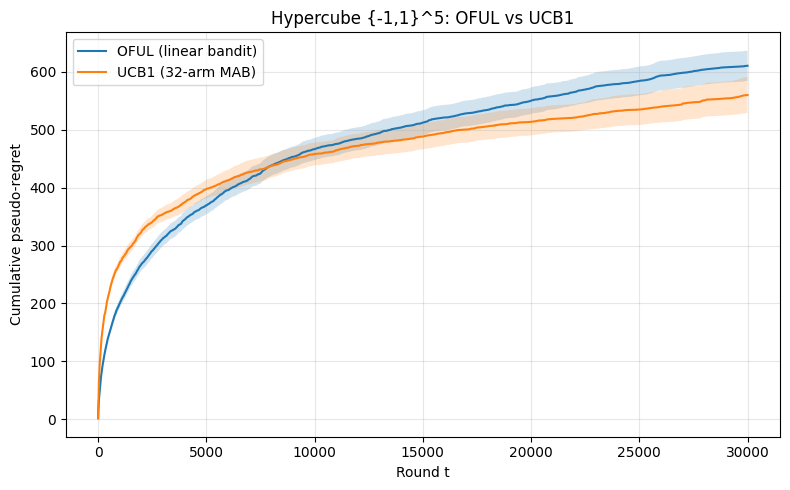

In [6]:
# Experiment 2: OFUL vs UCB1 on {-1,1}^5
actions = np.array(list(itertools.product([-1.0, 1.0], repeat=D_FINITE)), dtype=np.float64)

theta_stars_finite = np.empty((R_REPS, D_FINITE))
for i in range(R_REPS):
    local_rng = np.random.default_rng(int(rep_seeds[i] + 131 * i))
    th = local_rng.normal(size=D_FINITE)
    th /= np.linalg.norm(th)
    theta_stars_finite[i] = th

curves_oful = run_oful_finite_batch(N, actions, theta_stars_finite, rep_seeds)
curves_ucb1 = run_ucb1_finite_batch(N, actions, theta_stars_finite, rep_seeds + 2024)

mean_oful, se_oful = mean_and_se(curves_oful)
mean_ucb1, se_ucb1 = mean_and_se(curves_ucb1)

x = np.arange(1, N + 1)
fig, ax = plt.subplots(figsize=(8, 5))
plot_with_se(ax, x, mean_oful, se_oful, label="OFUL (linear bandit)")
plot_with_se(ax, x, mean_ucb1, se_ucb1, label="UCB1 (32-arm MAB)")

ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative pseudo-regret")
ax.set_title("Hypercube {-1,1}^5: OFUL vs UCB1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### observations

- In the unit-ball experiments (`d=5` and `d=10`), regret grows sublinearly with time, matching the expected behavior for OFUL.
- On the finite hypercube action set, OFUL typically outperforms UCB1 because it leverages linear structure across actions, while UCB1 treats each of the 32 vertices as an independent arm.
